# Unlabeled Data + Clustering (Unsupervised Learning)

So far, we’ve mostly worked with **supervised learning**: we had input features `X` and a known target label `y`, and the model learned a mapping from `X → y`.

In this project, we switch to **unsupervised learning**, where we typically have only **features `X`** and **no labels**.
That means there is no “correct answer” provided during training. Instead, the goal is to **discover structure** that is hidden inside the data.

---

## What “Clustering” Means

**Clustering** is the task of automatically grouping data points into clusters such that:

- Points **inside the same cluster** are **more similar** to each other
- Points **in different clusters** are **less similar** to each other

So clustering is basically:
> “Find natural groupings based on similarity.”

This is mainly used as an **exploratory** technique:
- It helps us organize messy data into meaningful structure
- It can reveal patterns we didn’t know existed
- It can also help with feature engineering, segmentation, and anomaly detection workflows later

---

## What We’ll Learn in This Project (High-Level)

We’ll cover three major clustering ideas:

### 1) **K-Means Clustering (finding centers of similarity)**
- One of the most widely used clustering algorithms
- It tries to represent each cluster using a **center point** (a “centroid”)
- The algorithm assigns points to clusters based on distance to these centers

### 2) **Hierarchical Clustering (bottom-up clustering tree)**
- Builds clusters step-by-step starting from individual points
- Produces a **tree-like structure** showing how clusters merge
- Useful when we want to explore cluster structure at multiple “levels”

### 3) **Density-Based Clustering (arbitrary shapes)**
- Finds clusters based on areas of **high point density**
- Useful when clusters are not “round” and can have irregular shapes
- Often better when we expect noise/outliers mixed in

---

## Why K-Means Is Useful (Real-World Examples)

K-means is commonly used for grouping things like:
- **Documents / news articles** by topic
- **Music / movies** by similarity patterns
- **Customer segmentation** (group customers with similar purchase behavior)
- **Recommendation engines** (group users/items with similar profiles)

---

## Key Mindset for This Project

Since we don’t have labels, clustering is not “right vs wrong” in the same way as supervised learning.
Instead, we judge clusters by:
- whether they look **coherent** and **separable**
- whether they are **useful** for the real task (segmentation, compression, insights, etc.)
- whether the grouping is **stable** across settings/parameters

## K-means Clustering with scikit-learn

K-means is one of the most widely used clustering algorithms because it is both **simple to understand** and **computationally efficient**. It belongs to the family of **prototype-based clustering methods**.

In prototype-based clustering, each cluster is represented by a **prototype**:
- For continuous numerical data, this prototype is usually the **centroid**, which is the average position of all points in the cluster.
- In some other settings, a cluster can be represented by a **medoid**, which is an actual data point that best represents the cluster.

The main idea of K-means is:
1. Choose the number of clusters, **k**
2. Assign points to the nearest cluster center
3. Recompute the cluster centers
4. Repeat until the assignments stop changing or improve only very little

A major strength of K-means is that it works very well when clusters are:
- compact
- well separated
- roughly spherical in shape

However, it also has an important limitation:
- we must choose the number of clusters **k** in advance

If we choose a poor value for **k**, the clustering result may not be very meaningful. Later, methods such as the **elbow method** and **silhouette analysis** are used to help decide a better value of **k**.

Although K-means can be applied to high-dimensional datasets, it is easier to understand visually using a **two-dimensional example**. In this project, we first generate a synthetic dataset with:
- 150 samples
- 2 features
- 3 cluster centers
- a relatively small cluster spread

This gives us a simple dataset where the points naturally form three visible groups. Plotting the data helps us see the cluster structure before applying the K-means algorithm itself.

This step is important because clustering is exploratory. Before fitting a clustering model, it is always useful to build intuition about how the data is distributed.


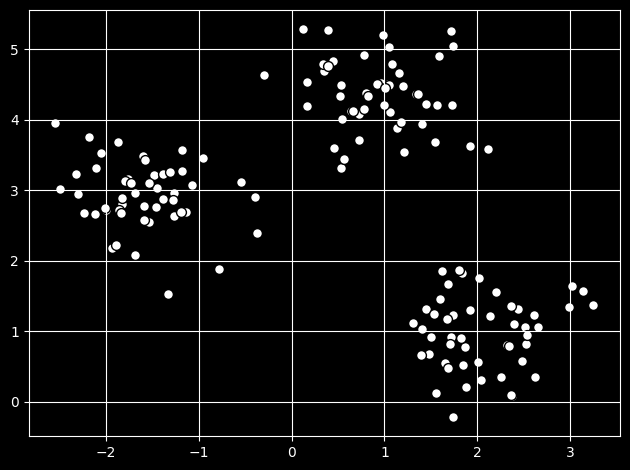

In [3]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=150,
    n_features=2,
    centers=3,
    cluster_std=0.5,
    shuffle=True,
    random_state=0
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c='white',
    marker='o',
    edgecolor='black',
    s=50
)

plt.grid()
plt.tight_layout()
plt.show()

## How K-means Clustering Works

In real clustering problems, we usually **do not have correct labels already given to us**.
That is what makes clustering different from supervised learning.

Our goal is to group data points based on **similarity**.
Points inside the same cluster should be **more similar to each other** than to points in other clusters.

K-means does this in a very simple iterative way.

### Main Steps of K-means

1. **Choose `k` initial centroids**
   - A centroid is the center of a cluster.
   - At the start, K-means picks `k` starting points as temporary cluster centers.

2. **Assign each example to the nearest centroid**
   - Every point is compared to each centroid.
   - The point joins the cluster whose centroid is closest.

3. **Update the centroid positions**
   - After the assignments, the centroid of each cluster is moved to the center of the points assigned to that cluster.

4. **Repeat**
   - Reassign points
   - Recompute centroids
   - Keep doing this until:
     - the assignments stop changing, or
     - a tolerance condition is reached, or
     - the maximum number of iterations is reached

This repeating process is why K-means is called an **iterative algorithm**.

---

## How Similarity is Measured

To cluster points, we need a way to measure how close or similar two points are.

In K-means, similarity is usually measured using **distance**.
Smaller distance means higher similarity.

The most common distance used here is the **squared Euclidean distance**.

In simple terms:
- take two points
- compare them feature by feature
- compute how far apart they are
- square those differences
- add them up

This gives a distance score.

### Intuition
- If two points are very close, the distance is small
- If two points are far apart, the distance is large

K-means uses this idea to decide which centroid a point should belong to.

---

## Why the Squared Euclidean Distance is Used

The squared Euclidean distance is useful because it:
- works well for continuous numerical data
- emphasizes larger distances more strongly
- fits naturally with the centroid-based structure of K-means

This is one reason K-means works best when clusters are:
- compact
- well separated
- roughly spherical in shape

---

## Important Notation Idea

The page also introduces notation:

- `j` refers to the **feature index**
- later, superscripts like `i` and `j` may be used for:
  - the index of a data point
  - the index of a cluster

You do not need to memorize the notation immediately.
The important practical idea is this:

**K-means repeatedly assigns points to the nearest center and then updates those centers until the grouping stabilizes.**

---

## Simple Mental Model

Think of K-means like this:

- Start with `k` temporary centers
- Pull each point toward the nearest center
- Move each center to the middle of its assigned points
- Repeat until the centers settle down

That is the heart of K-means clustering.

## K-means as an Optimization Problem

K-means is not just a grouping procedure. It can also be understood as an **optimization problem**.

The goal of the algorithm is to place cluster centroids in such a way that the points inside each cluster are as close as possible to their assigned centroid.

This objective is measured using the **sum of squared errors (SSE)**, which is also called:

- **within-cluster sum of squared errors**
- **cluster inertia**

### Main idea of SSE
For every point:
- look at the centroid of the cluster it belongs to
- measure the squared Euclidean distance from the point to that centroid
- add those values across all points

A good clustering result has a **small SSE**, because that means the data points are packed tightly around their cluster centers.

So the practical goal of K-means is:

**find cluster centers that minimize the within-cluster squared distances**

---

## Meaning of the Symbols

You do not need to memorize the notation, but the intuition is important:

- the centroid represents the center of a cluster
- each point belongs either to a given cluster or not
- if a point belongs to cluster `j`, its contribution is measured relative to centroid `j`

So the formula is simply a compact mathematical way of saying:

**“Add up the squared distance between each point and the center of the cluster it is assigned to.”**

---

## Applying K-means with scikit-learn

Now we use the `KMeans` class from scikit-learn.

### Important parameters used here

- `n_clusters=3`
  We ask the algorithm to form 3 clusters.

- `init='random'`
  The initial centroids are chosen randomly.

- `n_init=10`
  K-means is run 10 separate times with different random initial centroid choices.
  The best final result is chosen based on the lowest SSE.

- `max_iter=300`
  Each individual run is allowed up to 300 iterations.

- `tol=1e-04`
  This is the stopping tolerance.
  If the improvement becomes very small, the algorithm can stop early.

- `random_state=0`
  Makes the result reproducible.

---

## Why `n_init` matters

K-means can be sensitive to the initial placement of centroids.

If the algorithm starts from poor initial centers, it may converge to a weaker solution.
That is why we run it multiple times and keep the best one.

This is a very important practical point:
- K-means does **not always find the global best clustering**
- it can get stuck in a **local optimum**
- multiple restarts help reduce that problem

---

## Why `max_iter` and `tol` matter

K-means is iterative, so we need stopping rules.

- `max_iter` prevents the algorithm from running forever
- `tol` lets the algorithm stop when the cluster assignments or centroid movements become small enough

If `max_iter` is too small, the algorithm may stop before converging properly.
If it is too large, it may waste computation.

---

## Limitation of K-means

A major limitation is that we must specify the number of clusters **beforehand**.

That means:
- the algorithm does not automatically know the correct number of groups
- choosing the wrong number of clusters can reduce clustering quality

Another possible issue is that one or more clusters may become **empty**, meaning no data points are assigned to them during an iteration.

---

## Practical takeaway

This page shows that K-means is trying to minimize cluster compactness error, and that scikit-learn gives us direct control over:

- number of clusters
- centroid initialization
- number of restarts
- maximum iterations
- convergence tolerance

These settings are important because clustering quality depends not only on the data, but also on how the algorithm is initialized and allowed to converge.

In [4]:
from sklearn.cluster import KMeans

km = KMeans(
    n_clusters=3,
    init='random',
    n_init=10,
    max_iter=300,
    tol=1e-04,
    random_state=0
)

y_km = km.fit_predict(X)

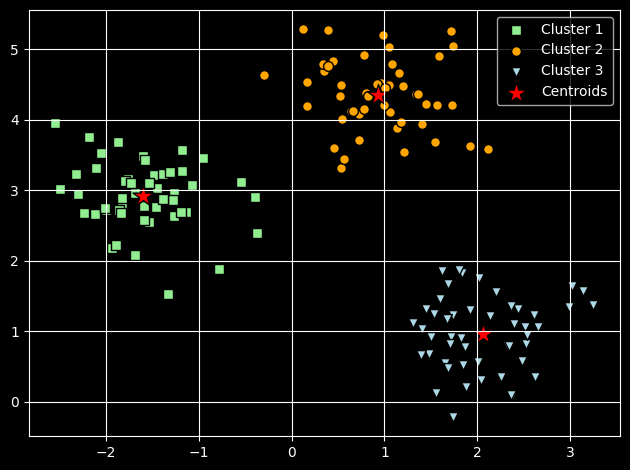

In [5]:
plt.scatter(
    X[y_km == 0, 0],
    X[y_km == 0, 1],
    s=50, c='lightgreen',
    marker='s', edgecolor='black',
    label='Cluster 1'
)

plt.scatter(
    X[y_km == 1, 0],
    X[y_km == 1, 1],
    s=50, c='orange',
    marker='o', edgecolor='black',
    label='Cluster 2'
)

plt.scatter(
    X[y_km == 2, 0],
    X[y_km == 2, 1],
    s=50, c='lightblue',
    marker='v', edgecolor='black',
    label='Cluster 3'
)

plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    s=250, marker='*',
    c='red', edgecolor='black',
    label='Centroids'
)

plt.legend(scatterpoints=1)
plt.grid()
plt.tight_layout()
plt.show()

## Visualizing K-means Clusters and Understanding Feature Scaling

After fitting the K-means model, we now have a cluster label assigned to every data point.
These predicted labels are stored in `y_km`.

The next step is to **visualize the clustering result** so we can see whether the algorithm grouped the data in a meaningful way.

### What this visualization shows

This plot separates the data points into their predicted clusters and also displays the **centroids**.

A centroid is the center of a cluster.
K-means keeps updating these centroids until the assignments stabilize or the stopping condition is reached.

So in this figure, we are plotting:

- all points assigned to cluster 1
- all points assigned to cluster 2
- all points assigned to cluster 3
- the final centroids learned by the model

This makes it easier to visually confirm whether the algorithm identified the three dense regions correctly.

---

## Why feature scaling matters in K-means

This section also highlights an important practical concept: **feature scaling**.

K-means uses **Euclidean distance** to decide which centroid is closest to a point.
Because of that, the scale of the features matters a lot.

For example:
- if one feature ranges from 0 to 1
- and another ranges from 0 to 10,000

then the larger-scale feature will dominate the distance calculation, even if it is not actually more important.

That is why, in real-world clustering problems, we usually make sure the features are measured on a comparable scale before applying K-means.

Common approaches include:

- **z-score standardization**
- **min-max scaling**

If the data is not scaled properly, K-means may produce misleading clusters.

---

## Empty cluster note

This section also mentions a practical issue with K-means: sometimes a cluster can become empty.

That means:
- a centroid exists
- but no points are currently assigned to it

In scikit-learn’s implementation, this is handled automatically.
If a cluster becomes empty, the algorithm reassigns the centroid to a point that is far away, helping the optimization continue.

---

## The `cluster_centers_` attribute

Once the model is fitted, scikit-learn stores the final centroid locations in:

`km.cluster_centers_`

This is a very important attribute because it gives the coordinates of the learned cluster centers.

In a two-dimensional dataset:
- the first column is the x-coordinate of each centroid
- the second column is the y-coordinate of each centroid

That is why we can plot the centroids directly.

---

## Practical takeaway

This page is about interpreting the output of K-means visually.

After clustering:
- `y_km` tells us which cluster each point belongs to
- `km.cluster_centers_` gives us the learned centroids

And from a machine learning perspective, the biggest lesson here is:

**K-means is highly sensitive to feature scale, so scaling should always be checked before clustering real-world data.**

## Limitations of K-means and Motivation for K-means++

In this section, we reflect on the behavior of standard K-means after visualizing the clustering result.

The clustering worked well on this toy dataset because the groups were clearly separated and roughly spherical. The centroids ended up near the center of each group, which is exactly what we would hope for.

However, this does **not** mean K-means is always reliable in real-world problems.

### Important limitations of standard K-means

#### 1. We must choose the number of clusters in advance
A major limitation of K-means is that we must specify the number of clusters, `k`, before running the algorithm.

This can be easy in a toy dataset where the groups are visually obvious, but in real-world datasets the correct number of clusters is often unclear.

This becomes even harder when:
- the data has many dimensions
- we cannot visualize it easily
- the structure is noisy or overlapping

---

#### 2. K-means assumes a certain cluster shape
K-means works best when clusters are:
- compact
- roughly spherical
- centered around a mean

If the real clusters are stretched, irregular, curved, or have very different densities, K-means may perform poorly.

---

#### 3. K-means is not hierarchical
K-means gives a flat partition of the data into `k` groups.

It does not tell us whether:
- some clusters are subgroups of larger clusters
- there is a nested structure in the data
- some points belong to coarse vs fine groupings

Later clustering methods handle this differently.

---

#### 4. K-means assumes clusters are non-empty
The algorithm expects that every cluster will contain at least one point.

In practice, empty clusters can happen during optimization, although modern implementations such as scikit-learn handle this internally.

---

## Why K-means++ is introduced

Another weakness of standard K-means is its **random initialization**.

If the initial centroids are chosen badly:
- clustering quality may become poor
- convergence may become slower
- the algorithm may settle into a weaker local solution

One simple workaround is to run K-means many times and keep the best result based on SSE.

A smarter solution is **K-means++**.

### Main idea of K-means++
K-means++ improves the initialization step by choosing better starting centroids instead of placing them completely at random.

This does not remove the deeper assumptions of K-means, such as:
- choosing `k` in advance
- preferring spherical clusters
- sensitivity to certain data shapes

But it often gives a **better starting point**, which leads to:
- faster convergence
- more stable clustering
- better final clustering quality

---

## Practical takeaway

This section teaches an important lesson:

A clustering result may look correct on a simple dataset, but we still need to understand the algorithm’s assumptions and weaknesses.

K-means++ is introduced as a smarter way to initialize centroids so that K-means becomes more reliable in practice.

## Understanding K-means++ Initialization and the Difference Between Hard and Soft Clustering

In this section, we move from the idea of K-means++ into the logic behind how it works.

Standard K-means may perform poorly if the initial centroids are chosen badly.
K-means++ improves this by trying to place the initial centroids **far away from one another**, so the algorithm starts from a more sensible configuration.

### Main intuition behind K-means++

The process begins by choosing the first centroid randomly.

After that, the remaining centroids are not chosen completely at random.
Instead, points that are **farther away from the centroids already selected** are given a **higher chance** of becoming the next centroid.

So the idea is:

- choose one centroid
- measure how far every other point is from the already chosen centroids
- prefer points that are far away
- repeat until all `k` centroids are selected
- then run regular K-means

This is useful because if the initial centroids are spread out, the algorithm is less likely to start from a poor configuration.

### Why K-means++ helps

K-means++ often improves clustering because:

- the initial centroids are better distributed
- convergence is often faster
- results are usually more stable
- the final clustering is often better than plain random initialization

In practice, K-means++ is the recommended default approach.

In scikit-learn, this is done using:

`init='k-means++'`

In fact, K-means++ is the default initialization strategy in scikit-learn.

---

## Hard versus soft clustering

This section also introduces an important conceptual distinction in clustering.

### Hard clustering
In **hard clustering**, each data point is assigned to **exactly one cluster**.

That means:
- one point belongs to one group only
- there is no overlap in membership
- the assignment is definite

K-means and K-means++ are examples of hard clustering methods.

---

### Soft clustering
In **soft clustering**, a data point can belong to **more than one cluster**.

Instead of saying:
- “this point belongs only to cluster 2”

soft clustering says something more like:
- “this point mostly belongs to cluster 2, but also partly to cluster 1”

This is useful when the data has overlap or uncertainty.

Soft clustering is also called **fuzzy clustering**.

A well-known example is **fuzzy C-means**, where each point gets a degree of membership for different clusters instead of a single fixed label.

---

## Why this distinction matters

Hard clustering is easier to interpret and works well when groups are clearly separated.

Soft clustering is more flexible and often more realistic when:
- cluster boundaries are unclear
- points lie between groups
- data naturally overlaps

So the main difference is:

- **hard clustering** = one point, one cluster
- **soft clustering** = one point can partially belong to multiple clusters

---

## Practical takeaway

This section teaches two important lessons:

1. **K-means++ improves the starting point of K-means by placing initial centroids more intelligently**
2. **not all clustering methods force a point into exactly one group — some methods allow partial membership across clusters**

This gives us a broader understanding of clustering beyond just the standard K-means algorithm.

## Soft Clustering with Fuzzy C-means and Motivation for the Elbow Method

In this section, we expand the clustering discussion beyond hard assignments.

So far, with K-means, every data point has been assigned to **exactly one cluster**.
That is called **hard clustering**.

Fuzzy C-means takes a different approach.

---

## Fuzzy C-means: Soft Clustering

In fuzzy C-means, a data point does not need to belong to only one cluster.

Instead, each point receives a **membership score** for every cluster.

For example, instead of saying:

- this point belongs only to cluster 2

we may say:

- 10% membership in cluster 1
- 85% membership in cluster 2
- 5% membership in cluster 3

These membership values behave like probabilities:

- each value lies between 0 and 1
- the memberships across all clusters add up to 1 for a given point

This makes fuzzy C-means useful when the cluster boundaries are not sharp and points may lie between groups.

---

## How fuzzy C-means works conceptually

The procedure is similar in spirit to K-means, but instead of assigning hard labels, it keeps updating soft memberships.

The algorithm can be understood in four main steps:

1. Choose the number of cluster centers and initialize the memberships randomly.
2. Compute the cluster centers based on those memberships.
3. Update the memberships of every point relative to the cluster centers.
4. Repeat steps 2 and 3 until the memberships stop changing much or a stopping rule is reached.

So the key difference is:

- **K-means** updates hard assignments
- **Fuzzy C-means** updates soft membership weights

---

## The role of the fuzziness coefficient

A very important concept here is the **fuzziness coefficient**, usually written as `m`.

This controls how soft or fuzzy the assignments become.

### Intuition:
- smaller values of `m` make the clustering behave more like hard clustering
- larger values of `m` make the memberships more spread out across clusters

So:

- if `m` is low, points strongly prefer one cluster
- if `m` is high, points share membership more evenly across multiple clusters

That means larger `m` produces **fuzzier clusters**.

---

## How cluster centers are computed in fuzzy C-means

In K-means, a centroid is just the average of the points assigned to that cluster.

In fuzzy C-means, the centroid is still a weighted average, but now each point contributes according to **how strongly it belongs to that cluster**.

So points with higher membership in a cluster influence that centroid more strongly.

This makes the centroids more flexible in overlapping regions of the data.

---

## Computational tradeoff

This section also points out an important practical observation:

- each iteration of fuzzy C-means is more expensive than an iteration of K-means
- however, fuzzy C-means may sometimes converge in fewer iterations overall

So there is a tradeoff between:
- richer membership information
- and extra computational cost per step

Also, fuzzy C-means is not currently implemented directly in scikit-learn.

---

## Why this matters in a project

Fuzzy C-means is useful when cluster membership should not be treated as absolute.

Examples:
- customers who behave like two customer groups at once
- documents that belong to multiple themes
- ambiguous data points near cluster boundaries

So this method gives a more realistic view when the data is overlapping or uncertain.

---

## Motivation for the elbow method

The next concept introduced here is the **elbow method**.

One of the biggest problems in clustering is that we usually do **not know the true number of clusters** in advance.

Unlike supervised learning:
- we do not have correct labels
- we do not have a direct accuracy score
- we cannot compare predictions against known answers

Because of that, clustering needs **intrinsic evaluation metrics**.

One of the most common is the **within-cluster sum of squared errors**, also called:
- distortion
- inertia
- cluster compactness error

The elbow method uses this quantity to compare clustering results for different values of `k`.

---

## Main idea of the elbow method

If we increase the number of clusters:
- the SSE usually decreases
- because smaller groups are easier to fit tightly

But adding more clusters forever is not helpful.

So we look for a point where the improvement starts to slow down sharply.

That bend in the curve is called the **elbow**.

The idea is:

- before the elbow, adding clusters improves the fit a lot
- after the elbow, adding clusters gives only small extra benefit

So the elbow gives us a practical guess for a reasonable number of clusters.

---

## Practical takeaway

This section broadens the project in two important ways:

1. It shows that clustering does not always need to be hard and exclusive — fuzzy C-means allows partial membership.
2. It introduces the elbow method as a practical tool for selecting the number of clusters when no true labels are available.

Together, these ideas make clustering more realistic and more useful for real-world exploratory analysis.

## Using the Elbow Method to Estimate the Number of Clusters

In this section, we use the **elbow method** to estimate a reasonable value for the number of clusters, `k`.

One of the biggest challenges in clustering is that we usually do not know the true number of groups in advance.
Since clustering is an unsupervised learning task, we do not have correct labels available, so we cannot use metrics such as accuracy in the same way we do in supervised learning.

Because of that, we need to rely on **intrinsic evaluation measures**.

---

## Distortion / Inertia / Within-cluster SSE

A common way to evaluate K-means clustering is by looking at the **within-cluster sum of squared errors**, also called:

- **distortion**
- **inertia**
- **within-cluster SSE**

This quantity measures how tightly the data points are grouped around their assigned cluster centroids.

### Intuition
- smaller distortion means points are closer to their centroids
- tighter clusters usually indicate a better clustering fit
- as we increase the number of clusters, distortion almost always decreases

That last point is important.

If we keep increasing `k`, the clusters become smaller and the data points get closer to their assigned centroids. So the distortion naturally drops.

But that does **not** mean we should always choose a very large `k`.

---

## Main idea of the elbow method

The elbow method helps us find a balance between:

- too few clusters
- too many clusters

We run K-means for several possible values of `k`, compute the distortion each time, and plot the result.

Then we look for the point where the curve changes sharply.

That bend is called the **elbow**.

### Interpretation
- before the elbow, increasing `k` gives a large improvement
- after the elbow, increasing `k` gives only small additional benefit

So the elbow is a practical estimate of a good number of clusters.

---

## Why scikit-learn makes this easier

When using scikit-learn, we do not need to compute the within-cluster SSE manually.

After fitting a K-means model, the value is already stored in:

`km.inertia_`

This gives us the distortion directly.

---

## What we do in this section

The workflow is simple:

1. Create an empty list to store distortion values.
2. Run K-means for `k = 1` through `k = 10`.
3. Fit the model each time.
4. Save the corresponding `inertia_` value.
5. Plot distortion against number of clusters.

Once the curve is plotted, we inspect where the elbow appears.

In this project, the elbow appears at **k = 3**, which supports the idea that three clusters are a good choice for this dataset.

---

## Practical takeaway

The elbow method is not a perfect rule, but it is one of the most useful and intuitive tools for estimating the number of clusters in K-means.

In this project, it confirms what we already observed visually:
the dataset is naturally grouped into **three clusters**.

In [6]:
print('Distortion: %.2f' % km.inertia_)

Distortion: 72.48


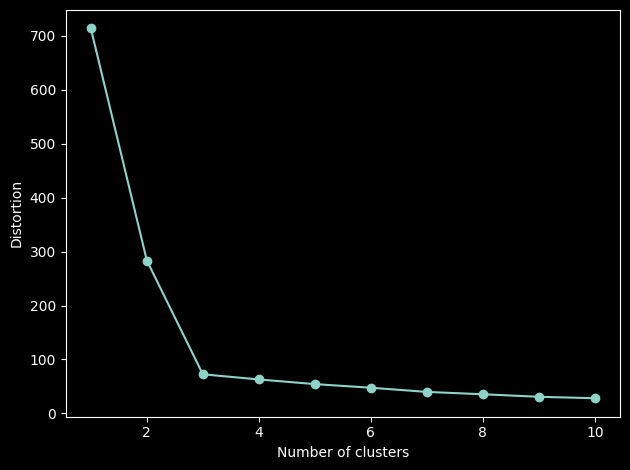

In [7]:
distortions = []

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=0
    )
    km.fit(X)
    distortions.append(km.inertia_)

plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.tight_layout()
plt.show()

## Evaluating Clustering Quality with Silhouette Analysis

In this section, we use **silhouette analysis** to evaluate how good a clustering result is.

The elbow method helps us estimate a reasonable number of clusters, but silhouette analysis gives us a more detailed view of **how well each sample fits inside its assigned cluster**.

---

## Main idea of silhouette analysis

For each data point, silhouette analysis compares two quantities:

### 1. Cohesion
This measures how close the point is to other points in the **same cluster**.

- low cohesion distance is good
- it means the point fits well inside its own cluster

### 2. Separation
This measures how far the point is from points in the **nearest neighboring cluster**.

- high separation distance is good
- it means the point is well separated from the next closest cluster

---

## Silhouette coefficient

The silhouette coefficient combines cohesion and separation into a single score.

Its value lies between **-1 and 1**.

### Interpretation
- **close to 1** → the point is well clustered
- **close to 0** → the point lies near a cluster boundary
- **less than 0** → the point may be assigned to the wrong cluster

So, larger silhouette values are better.

---

## Why silhouette plots are useful

A silhouette plot helps us inspect clustering quality visually.

It allows us to see:

- whether clusters are compact
- whether clusters are well separated
- whether some clusters contain weakly assigned points
- whether cluster sizes are balanced or very uneven
- whether the overall clustering is strong or suboptimal

This makes silhouette analysis more informative than just looking at distortion alone.

---

## Good clustering case

When the clustering is good:

- most silhouette values are clearly above 0
- many values are relatively high
- the average silhouette score is strong
- cluster bands look reasonably thick and consistent

That means the points are both:
- close to their own cluster members
- and separated from neighboring clusters

---

## Bad or suboptimal clustering case

When the clustering is weaker:

- the silhouette values become lower on average
- the band shapes may look uneven
- some points lie closer to 0
- the clusters may have very different widths and lengths

That is evidence that the chosen number of clusters may not match the real structure of the data very well.

In this project, the comparison between `k=3` and `k=2` helps show this clearly:

- `k=3` gives a better clustering structure
- `k=2` forces the data into too few groups, producing a weaker result

---

## Why this matters

In clustering, we do not have ground-truth labels available, so we need internal evaluation tools.

Silhouette analysis is one of the most useful tools because it helps us judge clustering quality not just globally, but also at the level of individual clusters and individual points.

So the main lesson of this section is:

- the elbow method suggests a good number of clusters
- silhouette analysis helps verify whether that clustering is actually well formed

In [9]:
# K-means with 3 clusters
from sklearn.cluster import KMeans

km = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    tol=1e-04,
    random_state=0
)

y_km = km.fit_predict(X)

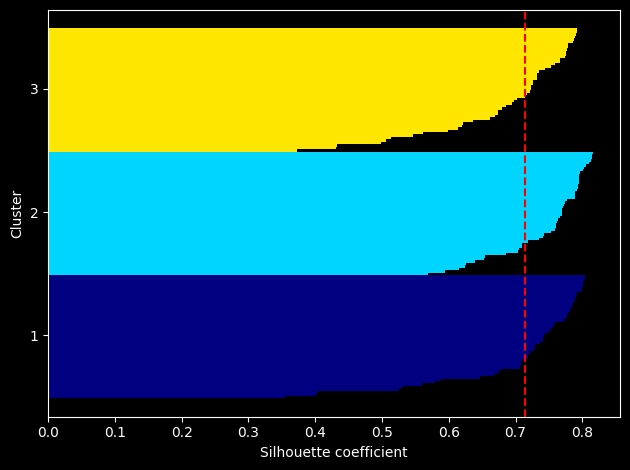

In [10]:
# Silhouette plot for k=3
import numpy as np
from matplotlib import cm
from sklearn.metrics import silhouette_samples

cluster_labels = np.unique(y_km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)

    plt.barh(
        range(y_ax_lower, y_ax_upper),
        c_silhouette_vals,
        height=1.0,
        edgecolor='none',
        color=color
    )

    yticks.append((y_ax_lower + y_ax_upper) / 2.0)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)

plt.axvline(silhouette_avg, color='red', linestyle='--')
plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')
plt.tight_layout()
plt.show()

In [11]:
# K-means with 2 clusters
km = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init=10,
    max_iter=300,
    tol=1e-04,
    random_state=0
)

y_km = km.fit_predict(X)

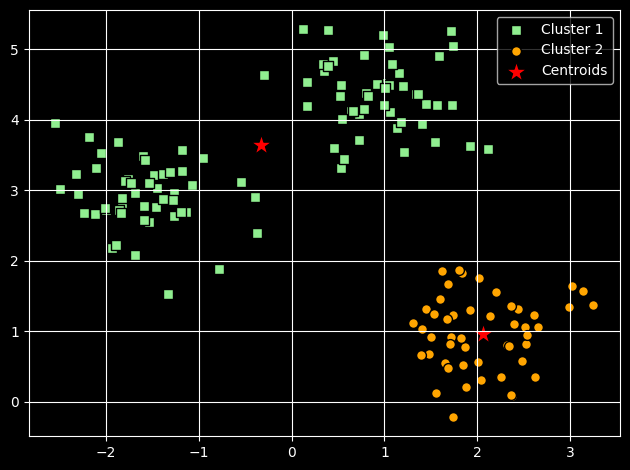

In [12]:
# Visualize the poorer clustering result (k=2)
plt.scatter(
    X[y_km == 0, 0],
    X[y_km == 0, 1],
    s=50,
    c='lightgreen',
    edgecolor='black',
    marker='s',
    label='Cluster 1'
)

plt.scatter(
    X[y_km == 1, 0],
    X[y_km == 1, 1],
    s=50,
    c='orange',
    edgecolor='black',
    marker='o',
    label='Cluster 2'
)

plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    s=250,
    marker='*',
    c='red',
    edgecolor='black',
    label='Centroids'
)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

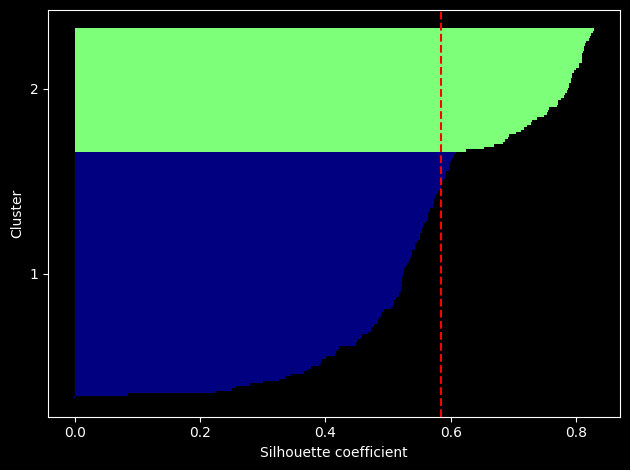

In [13]:
# Silhouette plot for k=2
cluster_labels = np.unique(y_km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)

    plt.barh(
        range(y_ax_lower, y_ax_upper),
        c_silhouette_vals,
        height=1.0,
        edgecolor='none',
        color=color
    )

    yticks.append((y_ax_lower + y_ax_upper) / 2.0)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)

plt.axvline(silhouette_avg, color='red', linestyle='--')
plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')
plt.tight_layout()
plt.show()

## Interpretation of the Silhouette Results

In this section, silhouette analysis helps us confirm that the clustering with **3 clusters** is better than the clustering with **2 clusters**.

For the `k=3` case, the silhouette coefficients are generally high and clearly positive, which indicates that the data points are well matched to their own clusters and reasonably separated from neighboring clusters.

For the `k=2` case, the clustering is more suboptimal. One centroid falls between two natural groups, and the silhouette plot shows more imbalance in the cluster shapes and lower-quality separation. This suggests that forcing the dataset into only two clusters does not reflect the true structure of the data as well as `k=3`.

So in this project, silhouette analysis supports the earlier conclusion from the elbow method: **3 clusters is the better choice** for this dataset.

## Hierarchical Clustering: Building Clusters as a Tree Structure

In this section, we move away from prototype-based clustering methods like K-means and begin studying **hierarchical clustering**.

Hierarchical clustering is useful because it organizes clusters into a **tree-like structure**, which can later be visualized using a **dendrogram**. This makes it easier to interpret how clusters are formed step by step.

A major advantage of hierarchical clustering is that we do **not need to specify the number of clusters upfront**. Instead, we can build the full hierarchy first and then decide where to cut the tree depending on how many clusters we want.

---

## Two main types of hierarchical clustering

### 1. Divisive hierarchical clustering
This is a **top-down** approach.

- Start with the entire dataset as one big cluster
- Repeatedly split it into smaller clusters
- Continue until every point becomes its own cluster

---

### 2. Agglomerative hierarchical clustering
This is a **bottom-up** approach.

- Start with each data point as its own individual cluster
- Repeatedly merge the closest clusters
- Continue until only one cluster remains

In this project section, we focus on **agglomerative hierarchical clustering**.

---

## Linkage methods

In agglomerative clustering, an important question is:

**How do we define the distance between two clusters?**

That depends on the **linkage method**.

### Single linkage
Single linkage measures the distance between the **most similar members** of two clusters.

So it asks:

**What is the shortest distance between any point in cluster A and any point in cluster B?**

This can create long, chain-like clusters.

---

### Complete linkage
Complete linkage measures the distance between the **most dissimilar members** of two clusters.

So it asks:

**What is the largest distance between any point in cluster A and any point in cluster B?**

This usually produces tighter, more compact clusters.

This is the linkage method used in this section.

---

### Other linkage methods
This section also briefly mentions two other common linkage strategies:

- **Average linkage**: uses the average distance between all pairs of points across two clusters
- **Ward linkage**: merges the clusters that cause the smallest increase in within-cluster SSE

---

## Steps of agglomerative clustering with complete linkage

The process can be understood in five steps:

1. Compute the distance matrix for all points
2. Treat each point as its own cluster
3. Merge the two closest clusters based on complete linkage
4. Update the distance matrix
5. Repeat until only one cluster remains

So unlike K-means, which keeps updating centroids, hierarchical clustering keeps merging clusters step by step.

---

## Why this section starts with a small random dataset

Before building a dendrogram or computing merges, we first need a small dataset that is easy to inspect manually.

That is why this section generates a tiny random dataframe with:

- 5 observations
- 3 features: `X`, `Y`, and `Z`
- row labels from `ID_0` to `ID_4`

This small dataset will be used in the next steps to compute the distance matrix and demonstrate how hierarchical clustering works.

---

## Practical takeaway

This section introduces a new way of thinking about clustering:

- K-means groups points around centroids
- hierarchical clustering builds a **merge history**

That merge history is powerful because it lets us study the structure of the data at multiple levels instead of committing to one fixed clustering immediately.

In [14]:
import pandas as pd
import numpy as np

np.random.seed(123)

variables = ['X', 'Y', 'Z']
labels = ['ID_0', 'ID_1', 'ID_2', 'ID_3', 'ID_4']

X = np.random.random_sample([5, 3]) * 10
df = pd.DataFrame(X, columns=variables, index=labels)

df

,X,Y,Z
ID_0,6.964692,2.861393,2.268515
ID_1,5.513148,7.194690,4.231065
ID_2,9.807642,6.848297,4.809319
ID_3,3.921175,3.431780,7.290497
ID_4,4.385722,0.596779,3.980443


## Performing Hierarchical Clustering from a Distance Matrix

In this section, we move from the conceptual idea of agglomerative hierarchical clustering into the actual computation.

The first step is to measure how far apart all observations are from one another. This is done by building a **distance matrix**.

---

## 1. Distance matrix

A distance matrix stores the pairwise distances between all observations in the dataset.

If two observations are very similar, their distance will be small.
If they are very different, their distance will be large.

In this project, we use **Euclidean distance**.

So for every pair of rows, we compute:

- how far they are from each other across the features `X`, `Y`, and `Z`

The result can be shown as a square matrix where:

- rows represent observations
- columns represent observations
- each cell contains the distance between two observations

The diagonal is always zero, because every point has zero distance from itself.

---

## 2. Condensed distance matrix vs square distance matrix

This section introduces an important practical detail.

SciPy's `pdist()` function returns a **condensed distance matrix**, not a full square table.

That means it gives the pairwise distances in a compact one-dimensional form.

If we want a readable symmetric table, we can convert it using `squareform()`.

So:

- `pdist(...)` → compact distance representation
- `squareform(...)` → full square matrix for display

This distinction matters because the hierarchical clustering function `linkage()` expects input in a specific way.

---

## 3. Correct vs incorrect usage of `linkage()`

This is one of the most important warnings in this section.

It may seem natural to pass the square distance matrix directly into `linkage()`, but that is **not the correct approach** in this case.

### Incorrect approach
Passing the squareform distance matrix directly to `linkage()` can produce incorrect results.

### Correct approaches
There are two correct ways to use `linkage()`:

1. pass the **condensed distance matrix** from `pdist(...)`
2. pass the **original data matrix** and specify the metric

Both are valid.

So the key lesson is:

- display the square matrix for understanding
- but use either the condensed matrix or the original input data when calling `linkage()`

---

## 4. What the linkage matrix means

After applying hierarchical clustering, SciPy returns a **linkage matrix**.

This matrix summarizes the merge history of the clustering process.

Each row represents one merge step.

The columns tell us:

- which two clusters or observations were merged
- the distance at which they were merged
- how many total items are contained in the new merged cluster

So the linkage matrix is the numerical summary of the full agglomerative clustering process.

---

## 5. What the dendrogram shows

Once we have the linkage matrix, we can visualize the clustering process using a **dendrogram**.

A dendrogram is a tree diagram that shows:

- which observations merge first
- which clusters merge later
- the distance at which each merge happens

### How to read it
- items that merge at a **low height** are more similar
- items that merge at a **high height** are less similar

So the dendrogram provides an interpretable picture of the clustering hierarchy.

In this project, the dendrogram helps us see which rows are most similar based on Euclidean distance.

---

## 6. Practical takeaway

This section is teaching the full pipeline for hierarchical clustering:

1. compute pairwise distances
2. apply agglomerative clustering using complete linkage
3. inspect the linkage matrix
4. visualize the structure with a dendrogram

This is powerful because hierarchical clustering does not just give one final grouping — it gives the full merge history of the data.

In [15]:
from scipy.spatial.distance import pdist, squareform

row_dist = pd.DataFrame(
    squareform(pdist(df, metric='euclidean')),
    columns=labels,
    index=labels
)

row_dist

,ID_0,ID_1,ID_2,ID_3,ID_4
ID_0,0.000000,4.973534,5.516653,5.899885,3.835396
ID_1,4.973534,0.000000,4.347073,5.104311,6.698233
ID_2,5.516653,4.347073,0.000000,7.244262,8.316594
ID_3,5.899885,5.104311,7.244262,0.000000,4.382864
ID_4,3.835396,6.698233,8.316594,4.382864,0.000000


In [16]:
from scipy.cluster.hierarchy import linkage

In [17]:
row_clusters = linkage(
    pdist(df, metric='euclidean'),
    method='complete'
)

In [18]:
row_clusters = linkage(
    df.values,
    method='complete',
    metric='euclidean'
)

In [19]:
pd.DataFrame(
    row_clusters,
    columns=['row label 1', 'row label 2', 'distance', 'no. of items in clust.'],
    index=['cluster %d' % (i + 1) for i in range(row_clusters.shape[0])]
)

,row label 1,row label 2,distance,no. of items in clust.
cluster 1,0.0,4.0,3.835396,2.0
cluster 2,1.0,2.0,4.347073,2.0
cluster 3,3.0,5.0,5.899885,3.0
cluster 4,6.0,7.0,8.316594,5.0


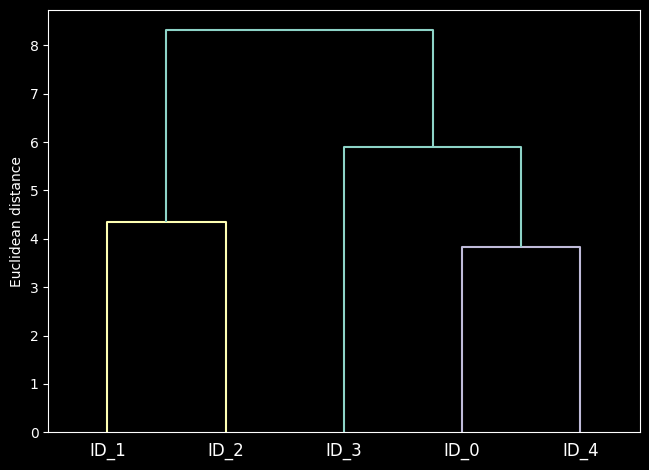

In [20]:
from scipy.cluster.hierarchy import dendrogram

row_dendr = dendrogram(
    row_clusters,
    labels=labels
)

plt.tight_layout()
plt.ylabel('Euclidean distance')
plt.show()

## Interpreting the Hierarchical Clustering Result

In this section, the distance matrix shows how far each observation is from every other observation based on the three features `X`, `Y`, and `Z`.

The linkage matrix then summarizes the agglomerative clustering process as a sequence of merges. Each row tells us which clusters were joined, the distance at which the merge happened, and how many total observations are contained in the merged cluster.

Finally, the dendrogram visualizes that merge history as a tree. Observations that join at lower heights are more similar, while those that merge at higher heights are less similar.

This gives us a full hierarchical view of the dataset rather than just one fixed partition.

## Combining a Dendrogram with a Heat Map

In this section, we combine hierarchical clustering with a heat map so that the clustering structure and the feature values can be viewed together.

A **dendrogram** shows how observations merge during hierarchical clustering.
A **heat map** shows the actual feature values using color intensity.

When we attach the dendrogram to the heat map, we get two kinds of information at the same time:

- the **hierarchical relationship** between observations
- the **numerical pattern of their feature values**

This is very useful because clustering alone tells us which observations are similar, but the heat map helps explain **why** they are similar by showing their feature profiles.

---

## Main idea of the procedure

The workflow is:

1. Draw the dendrogram on the left
2. Read the order of leaves from the dendrogram
3. Reorder the rows of the dataframe using that leaf order
4. Plot the reordered dataframe as a heat map
5. Clean up the plot and add labels

The important insight is that the row order of the heat map is not arbitrary.
It is rearranged to match the clustering order from the dendrogram.

That means nearby rows in the heat map are also nearby in the clustering tree.

---

## Why this is useful

This combined view gives us a compact visual summary of the dataset:

- similar observations appear near each other
- feature patterns become easier to compare
- the clustering structure becomes easier to interpret

So instead of looking at the dendrogram and the raw dataframe separately, we merge them into one interpretable visualization.

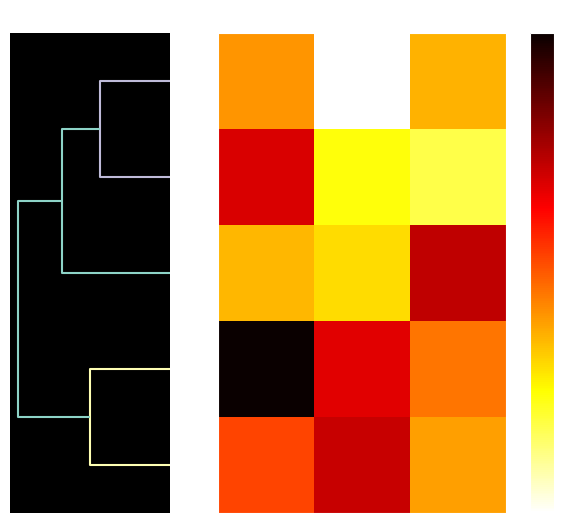

In [29]:
fig = plt.figure(figsize=(8, 8), facecolor='white')

axd = fig.add_axes([0.09, 0.1, 0.2, 0.6])

row_dendr = dendrogram(
    row_clusters,
    labels=labels,
    orientation='left'
)
df_rowclust = df.iloc[row_dendr['leaves'][::-1]]
df_rowclust
axm = fig.add_axes([0.23, 0.1, 0.6, 0.6])

cax = axm.matshow(
    df_rowclust,
    interpolation='nearest',
    cmap='hot_r'
)
axd.set_xticks([])
axd.set_yticks([])

for i in axd.spines.values():
    i.set_visible(False)

fig.colorbar(cax)

axm.set_xticks(range(len(df_rowclust.columns)))
axm.set_yticks(range(len(df_rowclust.index)))

axm.set_xticklabels(df_rowclust.columns)
axm.set_yticklabels(df_rowclust.index)

plt.show()

## Applying Agglomerative Clustering with scikit-learn

In this section, we repeat hierarchical clustering using scikit-learn instead of SciPy.

The main difference is that scikit-learn's `AgglomerativeClustering` allows us to directly request a fixed number of clusters.
This is useful when we want to **cut the hierarchical tree** at a chosen level and return a specific partition.

So instead of only studying the full merge history, we can also ask for a final grouping such as:

- 3 clusters
- 2 clusters
- or any other chosen number

This is often convenient in practical machine learning workflows.

---

## Important idea

Hierarchical clustering naturally creates a full tree of merges.
scikit-learn lets us **prune** that tree by choosing `n_clusters`.

So here the task becomes:

- use complete linkage
- use Euclidean distance
- request a specific number of final clusters

This gives us cluster labels directly.

---

## Interpretation

When we ask for 3 clusters, the result should match the structure we saw earlier in the dendrogram.

When we ask for 2 clusters, the algorithm cuts the hierarchy one level higher, creating a coarser grouping.

This is a nice reminder that hierarchical clustering does not force us into one single answer.
The final grouping depends on **where we cut the tree**.

In [26]:
# 3 clusters
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='complete'
)

labels = ac.fit_predict(X)
print('Cluster labels: %s' % labels)

Cluster labels: [1 0 0 2 1]


In [27]:
# 2 clusters
ac = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='complete'
)

labels = ac.fit_predict(X)
print('Cluster labels: %s' % labels)

Cluster labels: [0 1 1 0 0]


## Locating Dense Regions with DBSCAN

In this section, we study a density-based clustering algorithm called **DBSCAN**.

DBSCAN stands for **Density-Based Spatial Clustering of Applications with Noise**.

Unlike K-means, DBSCAN does not assume that clusters are spherical.
Unlike hierarchical clustering, DBSCAN does not require us to build a tree and then manually choose a cut level.

Instead, DBSCAN groups points based on **local density**.

---

## Core idea of DBSCAN

The algorithm looks at neighborhoods around points.

A point is examined using a radius called `eps`.

If enough neighboring points fall inside that radius, the point is treated as part of a dense region.

This leads to three important types of points:

### Core point
A point is a **core point** if at least a minimum number of neighbors fall within radius `eps`.

This means the point sits inside a dense region.

### Border point
A point is a **border point** if it does not itself have enough neighbors to be a core point, but it lies close enough to a core point to belong to that cluster.

### Noise point
A point is considered **noise** if it is neither a core point nor a border point.

So DBSCAN can leave some points unassigned, which is one of its major strengths.

---

## Why DBSCAN is useful

DBSCAN is especially powerful when the clusters are:

- irregularly shaped
- non-spherical
- mixed with noise or outliers

This makes it very different from K-means.

K-means tries to partition the data around centroids.
DBSCAN tries to discover dense connected regions.

---

## Key strength

The biggest advantage of DBSCAN is that it can detect **arbitrary-shaped clusters**.

That means it can succeed on datasets where K-means and even hierarchical clustering struggle.

---

## Important limitations

DBSCAN also has practical limitations:

- it can become harder to use in high-dimensional data
- performance depends strongly on choosing good values for `eps` and `min_samples`
- if cluster densities vary a lot, one global density threshold may not work well for all clusters

So DBSCAN is powerful, but it is still a method that needs tuning and judgment.

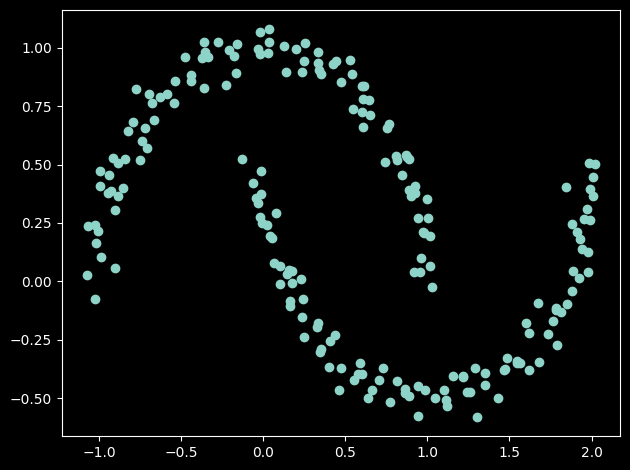

In [31]:
# Generate the half moon Dataset
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=200,
    noise=0.05,
    random_state=0
)

plt.scatter(X[:, 0], X[:, 1])
plt.tight_layout()
plt.show()

## Comparing K-means and Agglomerative Clustering on Nonlinear Data

In this section, we use a half-moon-shaped dataset to test whether the clustering methods we studied earlier can handle nonlinear structure.

This dataset is important because the true clusters are clearly **curved**, not spherical.

That makes it a good stress test.

### Why this matters
- K-means tends to prefer spherical partitions
- complete-linkage agglomerative clustering can also struggle with complex curved shapes

So this comparison helps show the limitation of those earlier methods on nonlinear cluster structures.

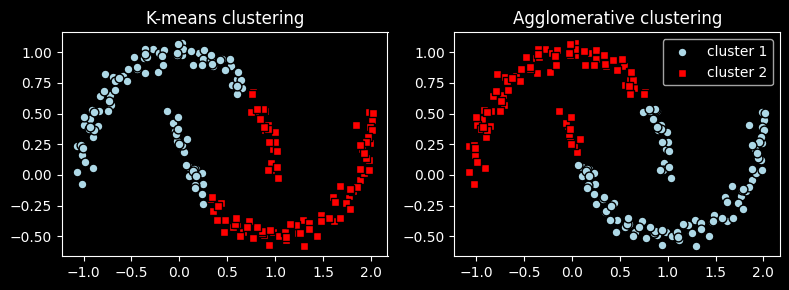

In [32]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

km = KMeans(n_clusters=2, random_state=0)
y_km = km.fit_predict(X)

ax1.scatter(
    X[y_km == 0, 0],
    X[y_km == 0, 1],
    c='lightblue',
    edgecolor='black',
    marker='o',
    s=40,
    label='cluster 1'
)

ax1.scatter(
    X[y_km == 1, 0],
    X[y_km == 1, 1],
    c='red',
    edgecolor='black',
    marker='s',
    s=40,
    label='cluster 2'
)

ax1.set_title('K-means clustering')

ac = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='complete'
)

y_ac = ac.fit_predict(X)

ax2.scatter(
    X[y_ac == 0, 0],
    X[y_ac == 0, 1],
    c='lightblue',
    edgecolor='black',
    marker='o',
    s=40,
    label='cluster 1'
)

ax2.scatter(
    X[y_ac == 1, 0],
    X[y_ac == 1, 1],
    c='red',
    edgecolor='black',
    marker='s',
    s=40,
    label='cluster 2'
)

ax2.set_title('Agglomerative clustering')

plt.legend()
plt.tight_layout()
plt.show()

## Interpreting the Nonlinear Clustering Comparison

In this section, both K-means and complete-linkage agglomerative clustering struggle to recover the true half-moon structure.

This happens because the data is not naturally organized into compact spherical groups.

K-means tries to split the data around centroids, which leads to an artificial partition.

Agglomerative clustering performs differently, but it is still challenged by the curved geometry of the dataset.

This comparison shows an important lesson:

A clustering method may work well on simple blob-shaped data and still fail on nonlinear cluster shapes.

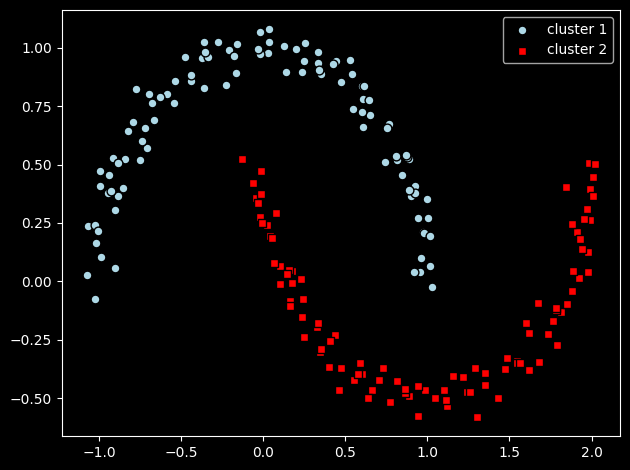

In [33]:
# DBSCAN on moons
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=0.2,
    min_samples=5,
    metric='euclidean'
)

y_db = db.fit_predict(X)

plt.scatter(
    X[y_db == 0, 0],
    X[y_db == 0, 1],
    c='lightblue',
    edgecolor='black',
    marker='o',
    s=40,
    label='cluster 1'
)

plt.scatter(
    X[y_db == 1, 0],
    X[y_db == 1, 1],
    c='red',
    edgecolor='black',
    marker='s',
    s=40,
    label='cluster 2'
)

plt.legend()
plt.tight_layout()
plt.show()

## Interpreting the DBSCAN Result

In this section, DBSCAN successfully detects the two half-moon-shaped clusters.

This highlights one of the major strengths of DBSCAN:

it can identify **non-spherical clusters** and does not force the data into centroid-based partitions.

This is exactly the kind of dataset where density-based clustering has an advantage over K-means and complete-linkage agglomerative clustering.

So the result demonstrates an important project lesson:

the choice of clustering algorithm should depend on the shape and structure of the data, not just on convenience.

## Final Note on Graph-Based Clustering

Beyond prototype-based, hierarchical, and density-based clustering, there is also a broader family of **graph-based clustering** methods.

One of the most well-known examples is **spectral clustering**.

These methods use similarity relationships between points, often represented as a graph or similarity matrix, to discover cluster structure.

Although this project does not implement spectral clustering directly, it is useful to know that clustering has many advanced variants beyond the methods covered here.

A practical lesson is that no single clustering algorithm is best for every dataset.

Successful clustering depends on:

- the shape of the data
- the chosen distance metric
- the algorithm and its hyperparameters
- and the use of domain knowledge

In many real applications, dimensionality reduction is also used before clustering so that the data becomes easier to analyze and visualize.

## Project Summary

In this project, we explored several major approaches to clustering as part of unsupervised learning.

We began with **K-means clustering**, where the goal was to group data points around centroids. We learned that K-means works best when clusters are compact and roughly spherical, but it requires the number of clusters to be chosen in advance.

To evaluate K-means, we used two important internal validation tools:

- the **elbow method**, which helped estimate a reasonable number of clusters
- **silhouette analysis**, which helped assess how well points fit inside their assigned clusters

Next, we studied **hierarchical agglomerative clustering**. Instead of assigning points directly to centroids, this method builds a full hierarchy of merges. We learned how to compute distance matrices, create linkage matrices, and visualize the merge history with a **dendrogram**. We also attached the dendrogram to a heat map to get a compact visual summary of clustered observations and their feature values.

We then applied **AgglomerativeClustering** from scikit-learn, which made it possible to cut the hierarchy into a specified number of final clusters.

After that, we explored **DBSCAN**, a density-based clustering method. This algorithm introduced the ideas of core points, border points, and noise points, and showed a major strength: it can discover clusters of arbitrary shape rather than assuming spherical structure.

The half-moon dataset provided a clear comparison:
- K-means struggled
- complete-linkage agglomerative clustering also struggled
- DBSCAN successfully recovered the two curved clusters

The overall lesson from this project is that clustering quality depends strongly on the structure of the data and on the assumptions of the algorithm being used.

### Key takeaways
- **K-means** is simple and efficient, but assumes compact spherical clusters
- **Hierarchical clustering** provides a full merge history and is highly interpretable
- **DBSCAN** is powerful for non-spherical clusters and noisy data
- internal validation methods like the **elbow method** and **silhouette analysis** are essential in unsupervised learning because ground-truth labels are usually unavailable

This project showed that clustering is not about blindly applying one algorithm. It is about understanding the data, testing multiple approaches, and choosing the method that best matches the structure of the problem.